In [344]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve

# Multiclass
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures,label_binarize

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.datasets import load_sample_image

# metrics

from sklearn.metrics import root_mean_squared_error

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score,\
                            classification_report, accuracy_score,\
                            precision_recall_curve,\
                            roc_curve,auc, roc_auc_score,\
                            ConfusionMatrixDisplay,\
                            root_mean_squared_error                      

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.cluster import MiniBatchKMeans

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
#====================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import initializers
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import sigmoid

import sys
from copy import deepcopy

import kagglehub
# =====================================
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,\
                                  getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors,goodnessOfFitTestOfParams



# Get details of dataset
https://online.stat.psu.edu/stat462/node/207/

The predictor variables are cellularity of the marrow clot section (CELL), smear differential percentage of blasts (SMEAR), percentage of absolute marrow leukemia cell infiltrate (INFIL), percentage labeling index of the bone marrow leukemia cells (LI), absolute number of blasts in the peripheral blood (BLAST), and the highest temperature prior to start of treatment (TEMP).

Qus: what is leukemia?
Leukemia is a type of cancer that affects the blood and bone marrow, leading to the production of abnormal white blood cells that don't function properly.
- It typically involves white blood cells, which are crucial for fighting infections. In leukemia, these cells become abnormal and multiply uncontrollably.



Please read about the dataset & varify the statement. All regressor variable are highely affect the remissions.


In [345]:
path = os.path.join(os.getcwd(), 'leukemia_remission.txt')
df = pd.read_csv(path)
df.columns
X = sm.add_constant(df.drop(['REMISS'],axis=1))
y = df['REMISS']
print(f'shape X: {X.shape}, Shape y: {y.shape}')

shape X: (27, 7), Shape y: (27,)


In [346]:
print(df.columns.values)
print(df.info())
print(df.describe())

['REMISS' 'CELL' 'SMEAR' 'INFIL' 'LI' 'BLAST' 'TEMP']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   REMISS  27 non-null     int64  
 1   CELL    27 non-null     float64
 2   SMEAR   27 non-null     float64
 3   INFIL   27 non-null     float64
 4   LI      27 non-null     float64
 5   BLAST   27 non-null     float64
 6   TEMP    27 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 1.6 KB
None
          REMISS       CELL      SMEAR      INFIL         LI      BLAST  \
count  27.000000  27.000000  27.000000  27.000000  27.000000  27.000000   
mean    0.333333   0.881481   0.635185   0.570741   1.003704   0.688519   
std     0.480384   0.186645   0.214052   0.237567   0.467795   0.534960   
min     0.000000   0.200000   0.320000   0.080000   0.400000   0.000000   
25%     0.000000   0.825000   0.430000   0.335000   0.650000   0.230000   
50%   

In [347]:
dfREMISS_1 = df[df['REMISS'] == 1]
dfREMISS_0 = df[df['REMISS'] == 0]

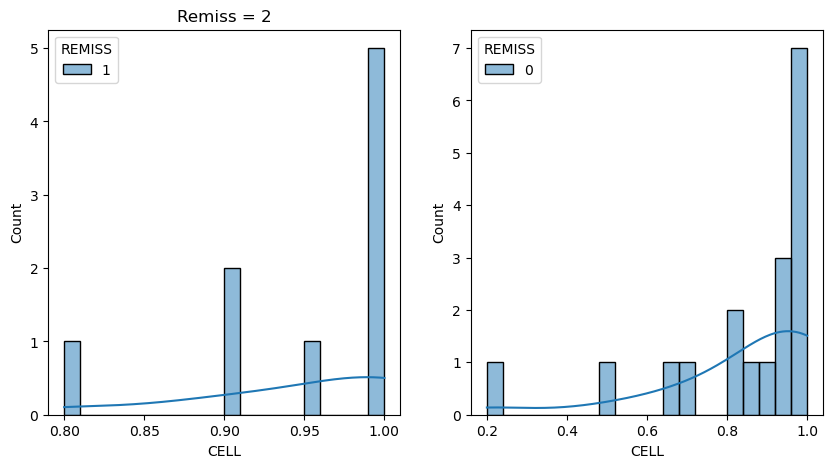

In [348]:
# Create a basic histogram
# Create a figure and a set of subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(data=dfREMISS_1, x="CELL",bins=20,kde=True,hue="REMISS",ax=ax1)
ax1.set_title("Remiss = 1")
sns.histplot(data=dfREMISS_0, x="CELL",bins=20,kde=True,hue="REMISS",ax=ax2)
ax1.set_title("Remiss = 2")
plt.show()

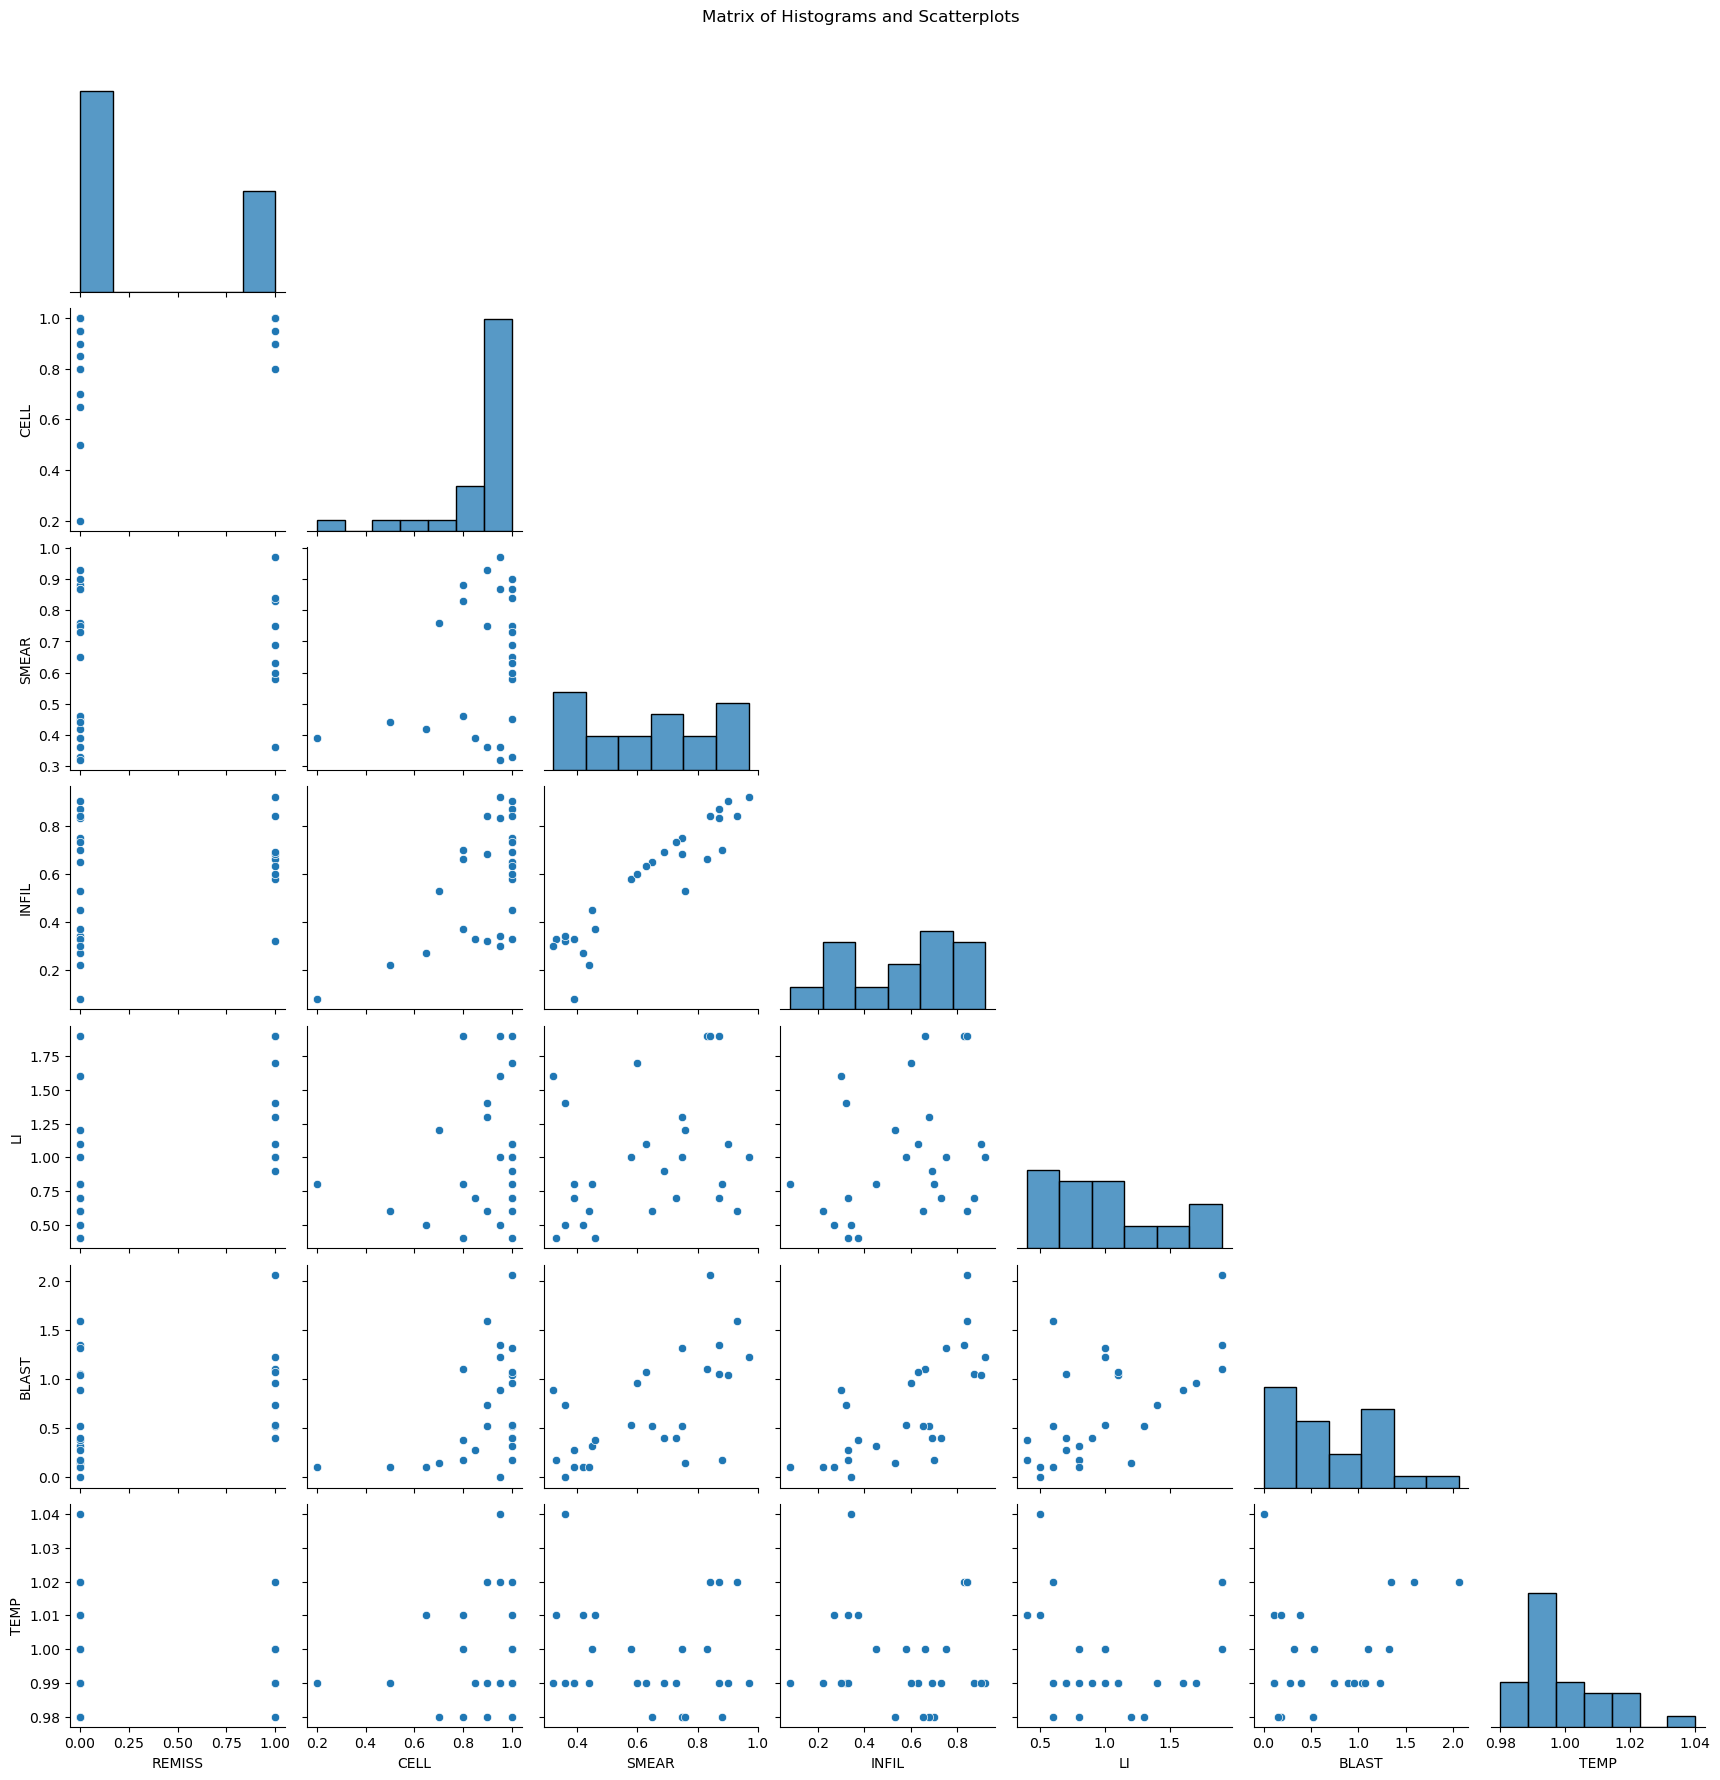

In [349]:
sns.pairplot(df, diag_kind='hist', corner=True,)
plt.suptitle("Matrix of Histograms and Scatterplots", y=1.02)
plt.show()

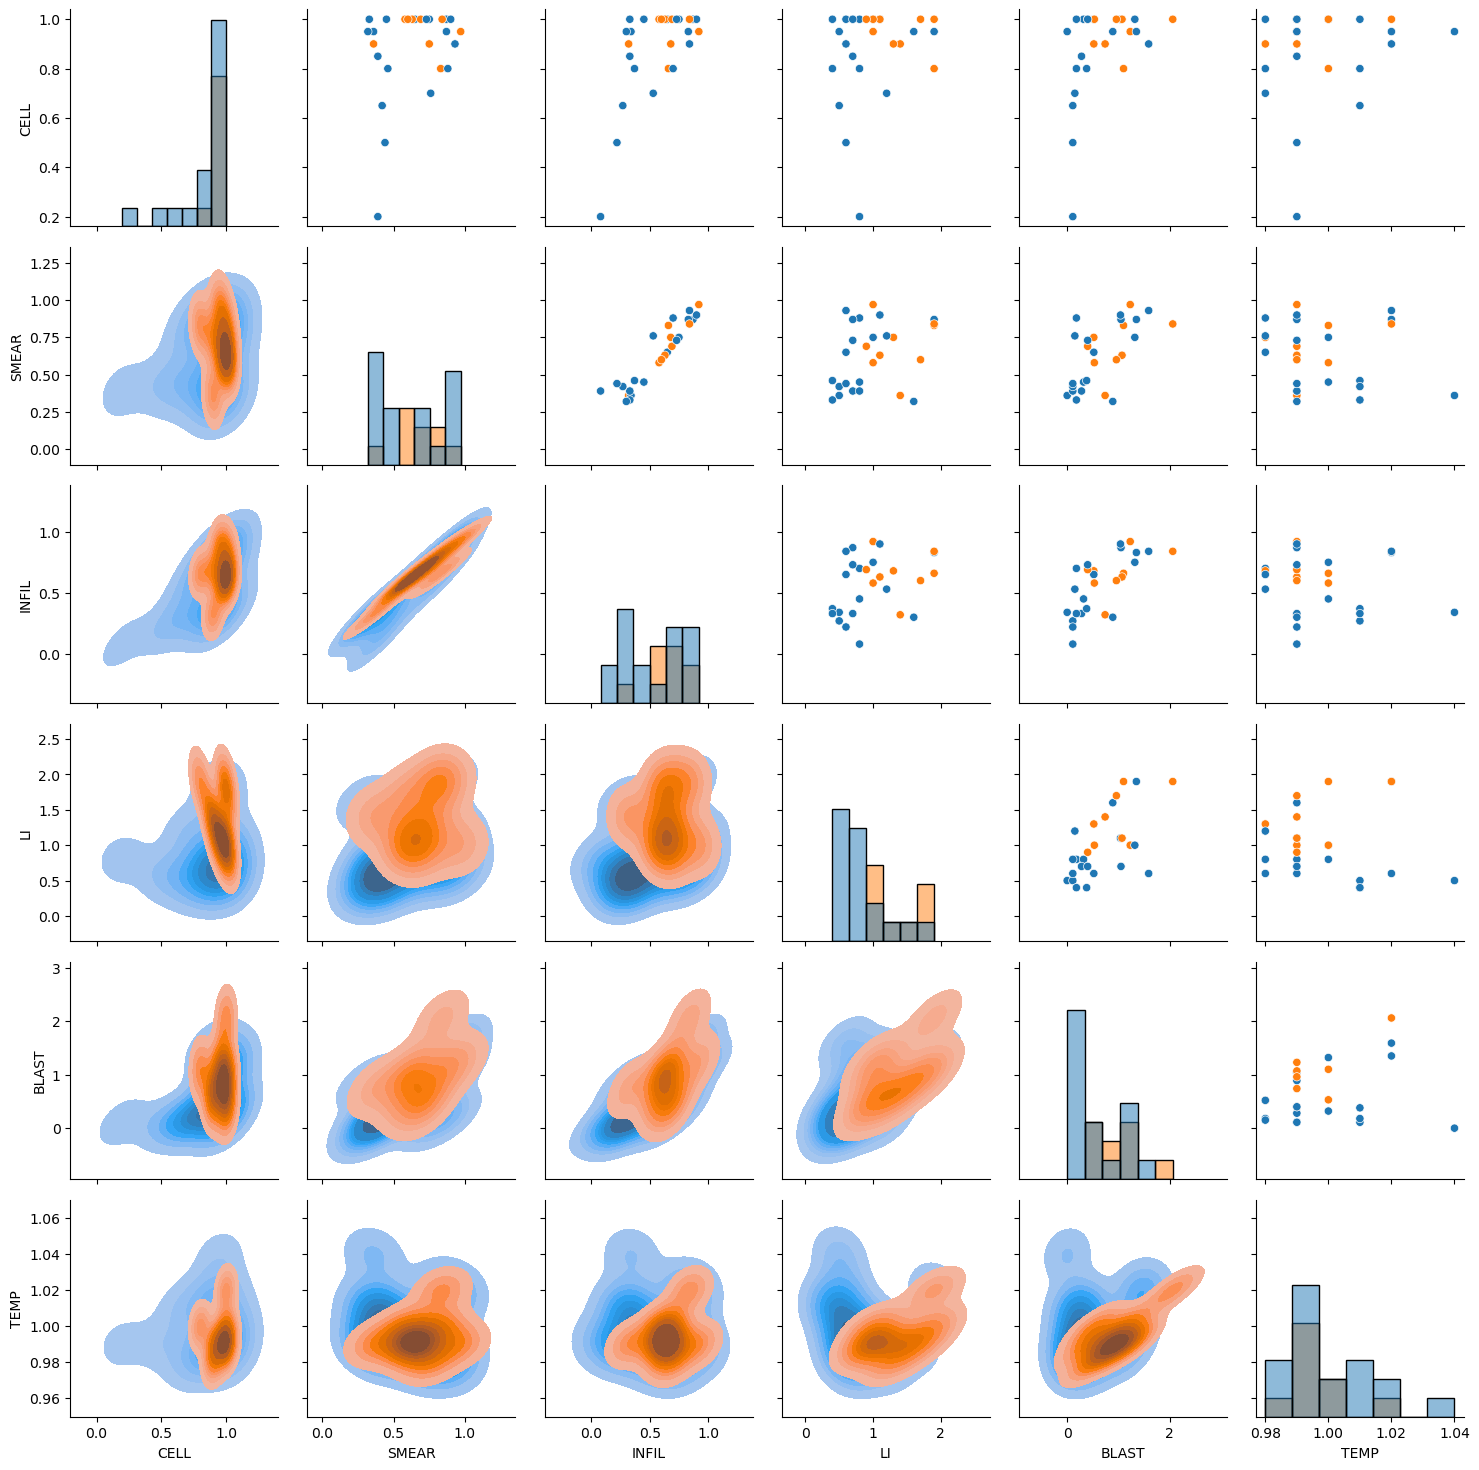

In [350]:
g = sns.PairGrid(df, hue="REMISS")
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot)

plt.show()


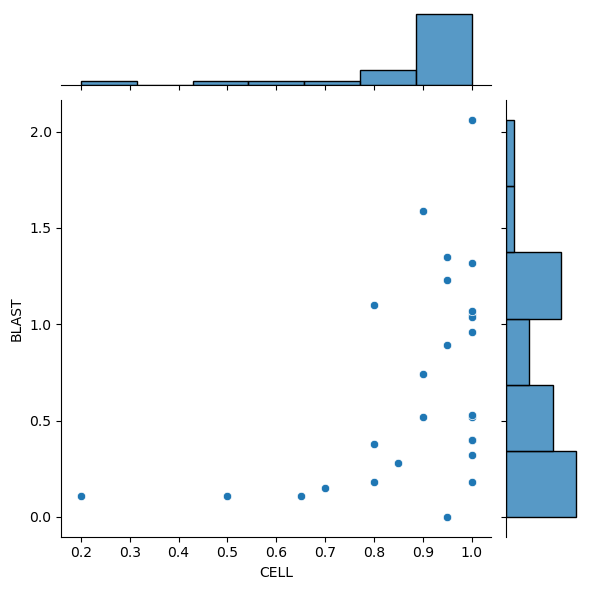

In [351]:
g = sns.JointGrid(data=df, x="CELL", y="BLAST")
g.plot(sns.scatterplot, sns.histplot)

plt.show()


Lower Triangular Correlation Matrix:
          REMISS      CELL     SMEAR     INFIL        LI     BLAST  TEMP
REMISS       NaN       NaN       NaN       NaN       NaN       NaN   NaN
CELL    0.264529       NaN       NaN       NaN       NaN       NaN   NaN
SMEAR   0.199488  0.291788       NaN       NaN       NaN       NaN   NaN
INFIL   0.263997  0.607077  0.929701       NaN       NaN       NaN   NaN
LI      0.541982  0.190235  0.317457  0.321144       NaN       NaN   NaN
BLAST   0.361188  0.440772  0.612348  0.695768  0.603877       NaN   NaN
TEMP   -0.143963  0.134832 -0.120395 -0.039825 -0.054002  0.216681   NaN


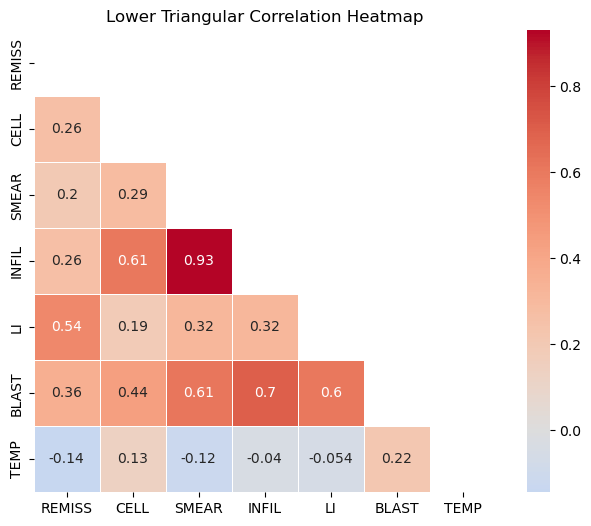

In [352]:
corr = df.corr(numeric_only=True)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
# Apply mask: set upper triangle to NaN
corr_lower = corr.mask(mask)

print("Lower Triangular Correlation Matrix:")
print(corr_lower)

# Plot heatmap with mask
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    mask=mask,          # hide upper triangle
    annot=True,         # show correlation values
    cmap="coolwarm",    # color palette
    center=0,           # center colormap at zero
    square=True,        # square cells
    linewidths=0.5
)
plt.title("Lower Triangular Correlation Heatmap")
plt.show()


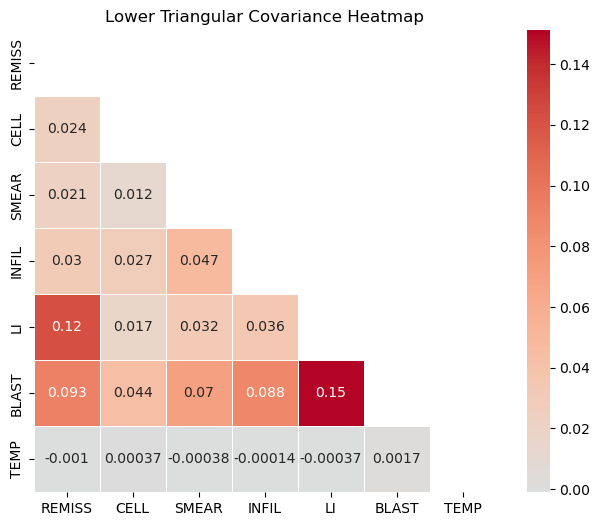

In [353]:
# Compute covariance matrix
cov = df.cov(numeric_only=True)
# Create a mask for the upper triangle
mask = np.triu(np.ones_like(cov, dtype=bool))

# Plot heatmap with mask
plt.figure(figsize=(8,6))
sns.heatmap(
    cov,
    mask=mask,          # hide upper triangle
    annot=True,         # show covariance values
    cmap="coolwarm",    # color palette
    center=0,           # center colormap at zero
    square=True,        # square cells
    linewidths=0.5
)
plt.title("Lower Triangular Covariance Heatmap")
plt.show()


#### Multicollinearity in statsmodels using the Variance Inflation Factor (VIF):

VIF quantifies how much the variance of a regression coefficient is inflated due to correlation among predictors. A VIF > 10 is often considered strong evidence of multicollinearity.

#### Interpret Results

- VIF = 1 → No correlation with other predictors.
- 1 < VIF < 5 → Moderate correlation, usually acceptable.
- VIF ≥ 10 → High multicollinearity, problematic.


In [354]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vifX = df.drop(['REMISS'],axis=1)
# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = vifX.columns
vif_data["VIF"] = [variance_inflation_factor(vifX.values, i) for i in range(vifX.shape[1])]
print(vif_data)


  feature         VIF
0    CELL  353.544213
1   SMEAR  699.858246
2   INFIL  776.585900
3      LI   11.181655
4   BLAST   10.105511
5    TEMP  318.223403


So we can see all regressor variable having VIF > 10. So Strong multicollinearity exixt. So we must have use Ridge regressions use in our model building.

TODO prepare models with Ridge regressions

In [355]:
# Calculate IQR
numeric_cols = df.select_dtypes(include='number').columns

# Function to detect outliers
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]

# Apply to each numeric column
outlier_summary = {}
for col in numeric_cols:
    outliers = detect_outliers_iqr(df[col])
    outlier_summary[col] = {
        'count': len(outliers),
        'indices': outliers.index.tolist()
    }

# Display summary
for col, info in outlier_summary.items():
    print(f"{col}: {info['count']} outliers → indices: {info['indices']}")

REMISS: 0 outliers → indices: []
CELL: 2 outliers → indices: [13, 18]
SMEAR: 0 outliers → indices: []
INFIL: 0 outliers → indices: []
LI: 0 outliers → indices: []
BLAST: 0 outliers → indices: []
TEMP: 1 outliers → indices: [9]


In [356]:
# Grouped Aggregation
grouped = df.groupby("REMISS").agg({
    "CELL": ["min","max","mean","var","std"],
    "SMEAR": ["min","max","mean","var","std"],
    "INFIL": ["min","max","mean","var","std"],
    "LI": ["min","max","mean","var","std"],
    "BLAST": ["min","max","mean","var","std"],
    "TEMP": ["min","max","mean","var","std"],
})
print(grouped)
print(df['REMISS'].value_counts())
print(grouped['SMEAR'])

       CELL                                    SMEAR                  \
        min  max      mean       var       std   min   max      mean   
REMISS                                                                 
0       0.2  1.0  0.847222  0.047198  0.217250  0.32  0.93  0.605556   
1       0.8  1.0  0.950000  0.005000  0.070711  0.36  0.97  0.694444   

                            ... BLAST                                      \
             var       std  ...   min   max      mean       var       std   
REMISS                      ...                                             
0       0.052191  0.228453  ...   0.0  1.59  0.554444  0.259708  0.509616   
1       0.032078  0.179103  ...   0.4  2.06  0.956667  0.256875  0.506828   

        TEMP                                      
         min   max      mean       var       std  
REMISS                                            
0       0.98  1.04  0.998889  0.000269  0.016410  
1       0.98  1.02  0.994444  0.000128  0.011304 

In [357]:
lnk = sm.genmod.families.links.Logit()
glm_binom = sm.GLM(y, X, family=sm.genmod.families.Binomial(link = lnk))
res = glm_binom.fit()
print(res.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 REMISS   No. Observations:                   27
Model:                            GLM   Df Residuals:                       20
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10.797
Date:                Thu, 13 Nov 2025   Deviance:                       21.594
Time:                        21:13:22   Pearson chi2:                     19.1
No. Iterations:                     8   Pseudo R-squ. (CS):             0.3770
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         64.2581     74.965      0.857      0.3

### 1. odds ratios

- Coefficients (β) are in log-odds, which are hard to interpret directly.
- Odds ratios (exp(β)) are intuitive: they show multiplicative changes in odds.

if OR > 1 : odds of outcome increse as xj increse
if OR < 1 : odds of outcome reduces as xj increse
if OR = 1 : No effect

In [358]:
# Log odds cofficient
coef = res.params
# Get -ve log odds
coef_n = coef[coef < 0]
# OR of -ve Log odds
conf_exp = np.exp(coef_n)
dfOr = pd.DataFrame({'LogOdds':coef_n,'OR':np.round(conf_exp,3)},index = coef_n.index)
tableDispFormatt('OR for -Ve Log Odds')
print(dfOr)
coef_p = coef[coef > 0]
# OR of +ve Log odds
conf_exp = np.exp(coef_p)
dfOrPov = pd.DataFrame({'LogOdds':coef_p,'OR':np.round(conf_exp,3)},index = coef_p.index)
tableDispFormatt('OR for +Ve Log Odds')
print(dfOrPov)

=============================== OR for -Ve Log Odds ========================================
          LogOdds     OR
INFIL  -24.974474  0.000
BLAST   -0.011531  0.989
TEMP  -100.173400  0.000
=============================== OR for +Ve Log Odds ========================================
         LogOdds            OR
const  64.258084  8.071075e+27
CELL   30.830061  2.450898e+13
SMEAR  24.686316  5.261758e+10
LI      4.360454  7.829300e+01


you can see INFL & TEMP not much affect the Odds ratio.
But you can see BLAST OR = 0.989 = 1 (approx)
- This means each unit increase in BLAST reduces the odds by (1 - 0.989) = 1.1%.

Similarly You can see in +Vs Odds ratio LI = 78.29
- This means each unit increase in L1 78 times the odds of the REMISS.

So we can see CELL and SMEAR strongly affect the outcome

- This means each unit increase in CELL 2.4*10^13 times the odds of the REMISS.
- This means each unit increase in SMEAR 5.26*10^10 times the odds of the REMISS.




Used to compare two nested models—one simpler (reduced) and one more complex (full)—to see if the added predictors significantly improve model fit.

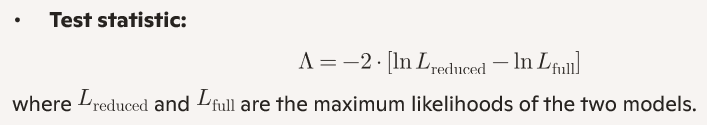

#### Hypothesis asumptions in LRT test

- **Null hypothesis (H₀)**: The reduced model (fewer predictors) fits the data adequately.
- **Alternative hypothesis (H₁)**: The full model (with extra predictors) provides a significantly better fit



In [359]:
mask = corr_lower > 0.9
filtered = corr_lower.where(mask)
print("\nFiltered DataFrame (only values > 0.9 shown):")
print(filtered)




Filtered DataFrame (only values > 0.9 shown):
        REMISS  CELL     SMEAR  INFIL  LI  BLAST  TEMP
REMISS     NaN   NaN       NaN    NaN NaN    NaN   NaN
CELL       NaN   NaN       NaN    NaN NaN    NaN   NaN
SMEAR      NaN   NaN       NaN    NaN NaN    NaN   NaN
INFIL      NaN   NaN  0.929701    NaN NaN    NaN   NaN
LI         NaN   NaN       NaN    NaN NaN    NaN   NaN
BLAST      NaN   NaN       NaN    NaN NaN    NaN   NaN
TEMP       NaN   NaN       NaN    NaN NaN    NaN   NaN


You can see correlation between INFIL & SMEAR > 0.9. So we can remove one variable and perform LRT. 

In [360]:
X_reduce  = X.drop(['INFIL'],axis = 1)
X_reduce = sm.add_constant(X_reduce)
lnk = sm.genmod.families.links.Logit()
glm_binom_reduse = sm.GLM(y, X_reduce, family=sm.genmod.families.Binomial(link = lnk))
res_reduse = glm_binom_reduse.fit()
X_reduce.shape, X.shape,res.df_model , res_reduse.df_model,df.shape

((27, 6), (27, 7), 6, 5, (27, 7))

In [361]:
# Log-likelihoods
llf_full = res.llf
llf_reduced = res_reduse.llf

# Degrees of freedom difference
df_diff = res.df_model - res_reduse.df_model
# Likelihood ratio statistic

llf_full = res.llf
llf_reduced = res_reduse.llf

lr_stat = -2 * (llf_reduced - llf_full)

# p-value from chi-square distribution
p_value = stats.chi2.sf(lr_stat, df_diff)

print("LR statistic:", np.round(lr_stat,3))
print("Degrees of freedom:", np.round(df_diff,3))
print("p-value:", np.round(p_value,3))

# Interpretation
if p_value < 0.05:
    print("→ Null hypothesis rejected!!!,\n→The full model significantly improves fit compared to the reduced model.")
if p_value >= 0.05:
    print("→ Fail to rejected null hypothesis!!!\n→ The reduced model is adequate; extra predictors may not add value.")



LR statistic: 0.154
Degrees of freedom: 1
p-value: 0.694
→ Fail to rejected null hypothesis!!!
→ The reduced model is adequate; extra predictors may not add value.


You can see, We are failed to reject Null hypothesis. Which state that, Redused Models are sufficient to descripe predicred value. And Ful models do not add significant result.

TODO 

In [362]:
mask = corr_lower > 0.6
filtered = corr_lower.where(mask)
print("\nFiltered DataFrame (only values > 0.6 shown):")
print(filtered)


Filtered DataFrame (only values > 0.6 shown):
        REMISS      CELL     SMEAR     INFIL        LI  BLAST  TEMP
REMISS     NaN       NaN       NaN       NaN       NaN    NaN   NaN
CELL       NaN       NaN       NaN       NaN       NaN    NaN   NaN
SMEAR      NaN       NaN       NaN       NaN       NaN    NaN   NaN
INFIL      NaN  0.607077  0.929701       NaN       NaN    NaN   NaN
LI         NaN       NaN       NaN       NaN       NaN    NaN   NaN
BLAST      NaN       NaN  0.612348  0.695768  0.603877    NaN   NaN
TEMP       NaN       NaN       NaN       NaN       NaN    NaN   NaN


TODO 
you can perform same test with another variable i.e. INFIL is 60% correlated with CELL. So you can check, If we remove INFIL, then reduse model are sufficient to prodused result.

### Check Check Accuracy reduced models and full models

In [363]:
tuned_thershold_probility = 0.5
predictions_prob_fm = (res.predict(X)>tuned_thershold_probility).astype(int)
predictions_prob_rm = (res_reduse.predict(X_reduce)>tuned_thershold_probility).astype(int)

acc_fm = accuracy_score(y, predictions_prob_fm)
acc_rm = accuracy_score(y, predictions_prob_rm)
print(f"thershold probabilityes: {tuned_thershold_probility} accureacy full models:{np.round(acc_fm,3)} accurecy reduse models {np.round(acc_rm,3)}")


thershold probabilityes: 0.5 accureacy full models:0.741 accurecy reduse models 0.778


You can see redused models accureacy better then full moldels.

### 3. goodness of fit using deviance

compare the null deviance (model with only intercept) and the residual deviance (your fitted model). 
A large drop in deviance means the predictors explain the data well. 
If residual deviance is close to the degrees of freedom, the model fits adequately

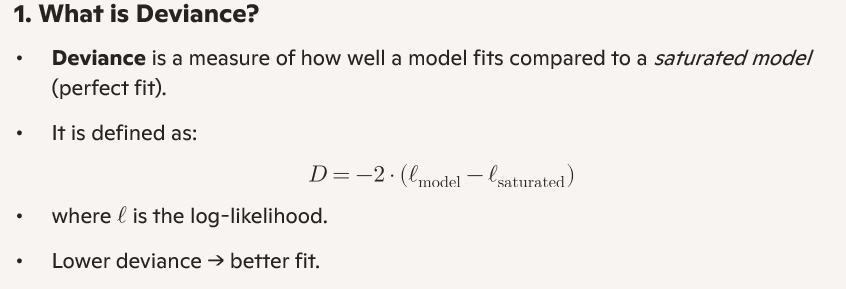


- Big drop from null to residual deviance = good fit.
- Residual deviance ≈ df_resid = adequate fit


In [364]:
# Access deviance values
print("Null deviance:", res.null_deviance)
print("Residual deviance:", res.deviance)
print("Degrees of freedom:", res.df_resid)

# Devience Thumrul test
llfmodel = res.llf * 2
llfnull  = res.llnull * 2
Deviance = -2 * (llfmodel - llfnull)
k_num_of_regressor = X.shape[1]-1
p_num_of_regressor = k_num_of_regressor + 1

Ratio = Deviance/(res.nobs - p_num_of_regressor)
print("Ratio:", Ratio)

Null deviance: 34.37176508791989
Residual deviance: 21.593848983017086
Degrees of freedom: 20
Ratio: -1.2777916104902804


#### Result Interpretation:

- Null deviance = 34.37
- Residual deviance = 21.59
- df_resid = 20

→ The drop in deviance (34.37 → 21.59) shows predictors explain the outcome well. 

Since residual deviance ≈(approx) df_resid, the model fits adequately

#### Ratio Test:

As per thumb rull id ***D/(n-p) >> 1*** then current models ***not*** adequate fit to data. 

But D/(n-p) = -1.277 << 1   then current models adequate fit to data.

#### 4. Pearson goodness-of-fit statistic

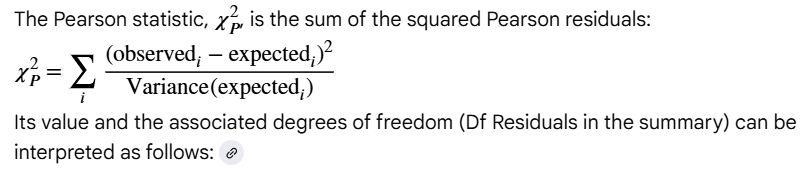

### Pearson residuals: 

Pearson residuals. The Pearson residuals are defined as **(endog - mu)/sqrt(VAR(mu))** where VAR is the distribution specific variance function. See statsmodels.families.family and statsmodels.families.varfuncs for more information.

#### Pearson’s Chi-Squared statistic

Pearson’s Chi-Squared statistic is defined as the sum of the squares of the Pearson residuals.

#### Result Interpretation:

The Pearson statistic
- Null Hypothesis: The model is a good fit for the data.
- Good Fit: For a correctly specified model, the Pearson statistic divided by its degrees of freedom (known as the dispersion statistic) should be approximately equal to 1.0.
- Lack of Fit / Overdispersion: If the ratio (Pearson \(\chi ^{2}\) / Df Residuals) is much larger than 1 (e.g., > 1.25), it suggests potential overdispersion or that the model is missing important explanatory variables or interaction terms. Overdispersion means there is more variability in the observed data than the model's assumed distribution can explain.
- Underdispersion: A ratio significantly less than 1 (rare in practice) suggests underdispersion.
- Hypothesis Test: For large samples, the statistic approximately follows a chi-squared distribution, allowing for a formal hypothesis test of the overall model fit. A large statistic value (and a small p-value, though the p-value is often not directly provided in the default summary for this specific statistic) indicates a statistically significant lack of fit

#### Pearson Chi-Squared statistic for full models

In [365]:
# Access the Pearson Chi-Squared statistic
pearson_chi2_statistic_fm = res.pearson_chi2
Pearson_residuals = res.resid_pearson
# Access degrees of freedom
dof = res.df_resid
print(f"Degrees of freedom: {dof}")

# Calculate the p-value for the goodness-of-fit test
p_value = chi2.sf(pearson_chi2_statistic_fm, dof)
print(f"P-value: {p_value}")

# Decision Rules:

significance_level = 0.05

if p_value < significance_level: 
    print("We hav sufficient evedance to Reject the null hypothesis.\n\
          This suggests that the observed data is significantly different from the expected data\n\
indicating that the model is a poor fit for the data.")
if p_value >= significance_level:
    print("Fail to reject null hypothesis !!!")
    print('This suggests the differences between the observed and expected values are\n\
likely due to chance, indicating that the model is a reasonable fit for the data.')


Degrees of freedom: 20
P-value: 0.517550560217422
Fail to reject null hypothesis !!!
This suggests the differences between the observed and expected values are
likely due to chance, indicating that the model is a reasonable fit for the data.


#### Pearson Chi-Squared statistic for Reduced models

In [366]:
# Access the Pearson Chi-Squared statistic
pearson_chi2_statistic_fm = res_reduse.pearson_chi2
Pearson_residuals = res_reduse.resid_pearson
# Access degrees of freedom
dof = res_reduse.df_resid
print(f"Degrees of freedom: {dof}")

# Calculate the p-value for the goodness-of-fit test
p_value = chi2.sf(pearson_chi2_statistic_fm, dof)
print(f"P-value: {p_value}")

# Decision Rules:

significance_level = 0.05

if p_value < significance_level: 
    print("We hav sufficient evedance to Reject the null hypothesis.\n\
          This suggests that the observed data is significantly different from the expected data\n\
indicating that the model is a poor fit for the data.")
if p_value >= significance_level:
    print("Fail to reject null hypothesis !!!")
    print('This suggests the differences between the observed and expected values are\n\
likely due to chance, indicating that the model is a reasonable fit for the data.')

Degrees of freedom: 21
P-value: 0.607322343405855
Fail to reject null hypothesis !!!
This suggests the differences between the observed and expected values are
likely due to chance, indicating that the model is a reasonable fit for the data.


We are getting the same result. So reduced models are also good & indicating that the model is a reasonable fit for the data.

#### Testing Hypotheses on Subsects of Parameters Using Deviance




In [367]:
# Deviance due to full models
Deviance_fm = Deviance

# We need to calculate Deviance after removing INFIL & SMEAR.

X_reduce_subset  = X.drop(['INFIL','SMEAR'],axis = 1)
X_reduce_subset = sm.add_constant(X_reduce_subset)
lnk = sm.genmod.families.links.Logit()
glm_binom_reduse = sm.GLM(y, X_reduce_subset, family=sm.genmod.families.Binomial(link = lnk))
res_reduse_subset = glm_binom_reduse.fit()

# Access deviance values
print("Null deviance:", res_reduse_subset.null_deviance)
print("Residual deviance:", res_reduse_subset.deviance)
print("Degrees of freedom:", res_reduse_subset.df_resid)

# Devience Thumrul test
llfmodel_subset = res_reduse_subset.llf * 2
llfnull_subset  = res_reduse_subset.llnull * 2
Deviance_reduce_subset = -2 * (llfmodel_subset - llfnull_subset)

print(f'Deviance due to full models: {Deviance_fm}')
print(f'Deviance due to reduse subdet models: {Deviance_reduce_subset}')

pearson_chi2_statistic_subset = res_reduse_subset.pearson_chi2
print(f'pearson_chi2_statistic_subset: {pearson_chi2_statistic_subset}')
dof_subset = res_reduse_subset.df_resid
print(f"Degrees of freedom: {dof_subset}")

# Calculate the p-value for the goodness-of-fit test
p_value = chi2.sf(pearson_chi2_statistic_subset, dof_subset)
print(f"P-value due to subset of models: {p_value}")

Deviance_subset = Deviance_fm - Deviance_reduce_subset
print(f'Devience due to INFIL & SMEAR only:{Deviance_subset}')
if abs(Deviance_reduce_subset) < pearson_chi2_statistic_subset:
    print('Reject Null hypothesis. Mence INFIL & SMEAR not play importent roll in models')
else:
    print('Fail to reject Null hypothesis. Mence INFIL & SMEAR play significent roal importent roll in models')

Null deviance: 34.37176508791989
Residual deviance: 21.869058634436854
Degrees of freedom: 22
Deviance due to full models: -25.555832209805608
Deviance due to reduse subdet models: -25.00541290696607
pearson_chi2_statistic_subset: 19.941903729149757
Degrees of freedom: 22
P-value due to subset of models: 0.5866739122711437
Devience due to INFIL & SMEAR only:-0.5504193028395363
Fail to reject Null hypothesis. Mence INFIL & SMEAR play significent roal importent roll in models


#### Wald Test in statsmodels

#### 1. Individual Parameter Tests (Default)

In [368]:
# Example: Test the joint hypothesis that the CELL coefficient is zero
# The restriction matrix R specifies the linear combination to test
# H0 -> CELL = 0 ; Do not play significent roale in modles

R = 'CELL = 0'
wald_result = res.wald_test(R)

# extract statistic, p-value and df if available
statistic = getattr(wald_result, "statistic", None)
p_value_wald = getattr(wald_result, "pvalue", None)
df_denom = getattr(wald_result, "df_denom", None)

# convert 0-d arrays to scalars for cleaner printing
if hasattr(statistic, "item"):
	try:
		statistic = statistic.item()
	except Exception:
		pass

if hasattr(p_value_wald, "item"):
	try:
		p_value_wald = p_value_wald.item()
	except Exception:
		pass

print("Wald statistic:", statistic)
print("p-value:", p_value_wald)
print("df_denom:", df_denom)

if p_value_wald < 0.05: 
    print('reject the null hypothesis !!!')
    print('This suggests that the variable(s)\n\
        being tested are significantly different\n\
    from the hypothesized value (usually zero)\n\
    and are therefore important predictors in the model.')
if p_value_wald >= 0.05:
    print('fail to reject the null hypothesis !!!')
    print('This suggests there is not enough evidence \n\
        to conclude that the variable(s) have a significant\n\
        effect, and they could potentially be removed from the\n\
        model without substantial loss of fit.')

Wald statistic: 0.3496927362160839
p-value: 0.5542871161862712
df_denom: 1.0
fail to reject the null hypothesis !!!
This suggests there is not enough evidence 
        to conclude that the variable(s) have a significant
        effect, and they could potentially be removed from the
        model without substantial loss of fit.


c:\Users\TODO\anaconda3\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


#### 2. Joint Hypothesis Testing



In [369]:

R = 'CELL = 0 , SMEAR = 0, INFIL = 0'
wald_result = res.wald_test(R)

# extract statistic, p-value and df if available
statistic = getattr(wald_result, "statistic", None)
p_value_wald = getattr(wald_result, "pvalue", None)
df_denom = getattr(wald_result, "df_denom", None)

# convert 0-d arrays to scalars for cleaner printing
if hasattr(statistic, "item"):
	try:
		statistic = statistic.item()
	except Exception:
		pass

if hasattr(p_value_wald, "item"):
	try:
		p_value_wald = p_value_wald.item()
	except Exception:
		pass

print("Wald statistic:", round(statistic,3))
print("p-value:", round(p_value_wald,3))
print("df_denom:", round(df_denom,3))

if p_value_wald < 0.05: 
    print('reject the null hypothesis !!!')
    print('This suggests that the variable(s)\n\
        being tested are significantly different\n\
    from the hypothesized value (usually zero)\n\
    and are therefore important predictors in the model.')
if p_value_wald >= 0.05:
    print('fail to reject the null hypothesis !!!')
    print('This suggests there is not enough evidence \n\
        to conclude that the variable(s) have a significant\n\
        effect, and they could potentially be removed from the\n\
        model without substantial loss of fit.')

Wald statistic: 1.272
p-value: 0.736
df_denom: 3.0
fail to reject the null hypothesis !!!
This suggests there is not enough evidence 
        to conclude that the variable(s) have a significant
        effect, and they could potentially be removed from the
        model without substantial loss of fit.


#### Confidence Intervals for Model Coefficients

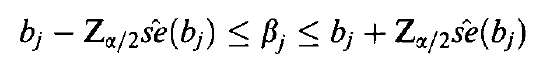

In [370]:
# Get a custom confidence interval (e.g., 95% CI)
conf_intervals_95 = res.conf_int(alpha=0.05)
conf_intervals_95.columns = ['Lower', 'Upper']
print("\n90% Confidence Intervals:")
print(conf_intervals_95)


90% Confidence Intervals:
            Lower       Upper
const  -82.670224  211.186392
CELL   -71.353061  133.013183
SMEAR  -95.902439  145.275071
INFIL -152.922646  102.973698
LI      -0.849084    9.569992
BLAST   -4.453485    4.430423
TEMP  -252.566262   52.219462


### CI for odds ratio

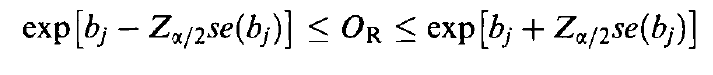

In [371]:
# CI for odds ratio
# 1. Get the original confidence intervals (on the log-odds scale)

conf_intervals_log_odds = res.conf_int(alpha=0.05)
conf_intervals_log_odds.columns = ['Lower CI (log-odds)', 'Upper CI (log-odds)']

# 2. Exponentiate the coefficients to get the Odds Ratios (ORs)
odds_ratios = np.exp(res.params)

# 3. Exponentiate the confidence interval bounds to get the CI for the ORs
conf_intervals_ors = np.exp(conf_intervals_log_odds)
conf_intervals_ors.columns = ['Lower CI (OR)', 'Upper CI (OR)']

# Combine into a single, readable DataFrame
results_df = pd.DataFrame({
    'Odds Ratio': odds_ratios,
    'Lower CI (OR)': conf_intervals_ors['Lower CI (OR)'],
    'Upper CI (OR)': conf_intervals_ors['Upper CI (OR)']
})

print(results_df)

         Odds Ratio  Lower CI (OR)  Upper CI (OR)
const  8.071075e+27   1.249620e-36   5.212966e+91
CELL   2.450898e+13   1.027447e-31   5.846437e+57
SMEAR  5.261758e+10   2.239237e-42   1.236408e+63
INFIL  1.424701e-11   3.859569e-67   5.259067e+44
LI     7.829267e+01   4.278067e-01   1.432830e+04
BLAST  9.885353e-01   1.163794e-02   8.396695e+01
TEMP   3.127844e-44  2.050529e-110   4.771164e+22


### Variance (Compute the variance/covariance matrix.)

 is an n x n diagonal matrix containing the estimated variance of each observation on the main diagonal; that is, the ith diagonal element of V is
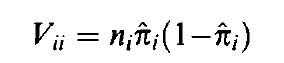

In [372]:
# Get the full variance-covariance matrix
cov_matrix = res.cov_params()
print("\nVariance-Covariance Matrix of Coefficients:")
print(cov_matrix)


Variance-Covariance Matrix of Coefficients:
             const         CELL        SMEAR        INFIL          LI  \
const  5619.721251 -1284.243010 -1778.467647  1898.267716   64.200040   
CELL  -1284.243010  2718.079478  3150.748440 -3328.696701   39.881476   
SMEAR -1778.467647  3150.748440  3785.449360 -4009.098900   26.495992   
INFIL  1898.267716 -3328.696701 -4009.098900  4261.593164  -23.341575   
LI       64.200040    39.881476    26.495992   -23.341575    7.064838   
BLAST    21.993741    14.223129    29.445671   -36.250277   -3.345964   
TEMP  -4536.184440 -1362.077863 -1268.602196  1309.052029 -111.273210   

           BLAST         TEMP  
const  21.993741 -4536.184440  
CELL   14.223129 -1362.077863  
SMEAR  29.445671 -1268.602196  
INFIL -36.250277  1309.052029  
LI     -3.345964  -111.273210  
BLAST   5.136319   -32.710271  
TEMP  -32.710271  6045.511760  


### 2. The Model's Dispersion/Scale Parameter

A GLM assumes a specific relationship between the mean and the variance based on its chosen family (e.g., Poisson assumes variance equals the mean). The model estimates a scale parameter (dispersion) to account for extra variability (overdispersion or underdispersion).


In statsmodels, this scale parameter is estimated during the fit:

- For models like Gaussian (Normal) linear regression, the scale parameter is the residual variance sigma^2
- For Poisson and Binomial models, the theoretical scale is fixed at 1, but if the actual data is overdispersed, statsmodels estimates a larger value using methods like Pearson residuals.

In [373]:
# Access the estimated scale parameter (dispersion)
model_scale = res.scale
print(f"Estimated model scale parameter: {model_scale}")

# You can force statsmodels to estimate the scale parameter using Pearson Chi-squared
# This is useful when checking for overdispersion
model_pearson_scale = res.estimate_scale(method='pearson')
print(f"Estimated scale using Pearson method: {model_pearson_scale}")

Estimated model scale parameter: 1.0


AttributeError: 'GLMResults' object has no attribute 'estimate_scale'

#### 3. The Theoretical Variance Function

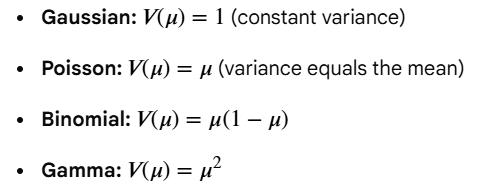

In [ ]:
# Access the variance function of the family object
variance_function = res.family.variance
print(f"Variance function object: {variance_function}")

# You can calculate the theoretical variance for predicted mean values (mu)
predicted_means = res.fittedvalues
# This calculates V(mu) for each observation based on the chosen family
theoretical_variances = res.family.variance(predicted_means)

Variance function object: <statsmodels.genmod.families.varfuncs.Binomial object at 0x000002B1D001A420>


In [ ]:
# Access the variance function of the family object
variance_function = res.family.variance
print(f"Variance function object: {variance_function}")

# You can calculate the theoretical variance for predicted mean values (mu)
predicted_means = res.fittedvalues
# This calculates V(mu) for each observation based on the chosen family
theoretical_variances = res.family.variance(predicted_means)

In [ ]:
X.loc[1:1,:]

,const,CELL,SMEAR,INFIL,LI,BLAST,TEMP
1,1.0,0.9,0.36,0.32,1.4,0.74,0.99


### Qus Find a CI on the linear predictor at any set of values of the predictor variables that is of interest.
Let we want to check CI of

CELL	SMEAR	INFIL	LI	BLAST	TEMP

0.8	    0.88	0.7	   0.8	0.18	0.98

In [ ]:
# Get Predicted Probability for a single new observation
# X0 must align with model parameter order (const, CELL, SMEAR, INFIL, LI, BLAST, TEMP)
#X0 = np.array([1, 0.8, 0.88, 0.7, 0.8, 0.18, 0.98])
X0 = np.array([1.0,	0.9	,0.36,	0.32	,1.4	,0.74,	0.99])
#X0 = np.array(X.loc[1:1,:])
X0_2d = X0.reshape(1, -1)

# Predicted probability (model's predict returns probability for a Binomial/Logit link)
predicted_prob = float(res.predict(X0_2d).squeeze())
print("\nPredicted probability (response scale):", np.round(predicted_prob, 6))

# Compute CI for the linear predictor (eta = X0 @ params)
# Variance of linear predictor: Var(eta) = X0' * cov_params * X0
var_eta = float(X0 @ cov_matrix.values @ X0)
se_eta = np.sqrt(var_eta)

# 95% CI on linear predictor (normal approximation / delta method)
from scipy.stats import norm as _norm
z = _norm.ppf(0.975)

eta_hat = float(X0 @ res.params)
ci_eta_lower = eta_hat - z * se_eta
ci_eta_upper = eta_hat + z * se_eta

# Transform to probability scale using logistic (inverse logit)
def _inv_logit(x):
	return 1.0 / (1.0 + np.exp(-x))

ci_prob_lower = _inv_logit(ci_eta_lower)
ci_prob_upper = _inv_logit(ci_eta_upper)

print("\nLinear predictor (eta):", np.round(eta_hat, 6))
print(f"95% CI for eta: [{ci_eta_lower:.6f}, {ci_eta_upper:.6f}]")
print(f"95% CI for probability: [{ci_prob_lower:.6f}, {ci_prob_upper:.6f}]")

# Optional: use statsmodels prediction object to verify (returns mean and CI on response scale)
pred_obj = res.get_prediction(X0_2d)
pred_df = pred_obj.summary_frame(alpha=0.05)  # default is response scale for GLM with link
print("\nstatsmodels get_prediction summary_frame (response scale):")
print(pred_df[['mean', 'mean_ci_lower', 'mean_ci_upper']])


Predicted probability (response scale): 0.456316

Linear predictor (eta): -0.175182
95% CI for eta: [-3.383571, 3.033206]
95% CI for probability: [0.032813, 0.954052]

statsmodels get_prediction summary_frame (response scale):
       mean  mean_ci_lower  mean_ci_upper
0  0.456316       0.032813       0.954052


#### Akaike Information Criterion (AIC):

Key metric used to compare models by balancing goodness-of-fit with model complexity.

- Lower AIC values indicate better models.

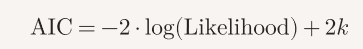

In [ ]:
print(f'AIC Full Models: {res.aic}')
print(f'AIC reduce Models [remove INFIL regressosr]: {res_reduse.aic}')
print(f'AIC reduce Models [remove INFIL SMEA regressosr]: {res_reduse_subset.aic}')

AIC Full Models: 35.59384898301708
AIC reduce Models [remove INFIL regressosr]: 33.74826493666019
AIC reduce Models [remove INFIL SMEA regressosr]: 31.869058634436854


The minimum AIC value is observed when the INFIL SMEA regressor is removed. However, we have previously shown that models excluding the INFIL SMEA regressor do not adequately fit the data, rendering the AIC result unreliable.

### Bayes Information Criterion

In [ ]:
print(f'BIC Full Models: {res.bic}')
print(f'BIC reduce Models [remove INFIL regressosr]: {res_reduse.bic}')
print(f'BIC reduce Models [remove INFIL SMEA regressosr]: {res_reduse_subset.bic}')

BIC Full Models: -44.3228883370695
BIC reduce Models [remove INFIL regressosr]: -47.46430924943071
BIC reduce Models [remove INFIL SMEA regressosr]: -50.63935241765839


c:\Users\TODO\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


In [ ]:
print(f'Based on the devianc Full Models: {res.bic_deviance}')
print(f'Based on the devianc reduce Models [remove INFIL regressosr]: {res_reduse.bic_deviance}')
print(f'Based on the devianc reduce Models [remove INFIL SMEA regressosr]: {res_reduse_subset.bic_deviance}')

Based on the devianc Full Models: -44.3228883370695
Based on the devianc reduce Models [remove INFIL regressosr]: -47.46430924943071
Based on the devianc reduce Models [remove INFIL SMEA regressosr]: -50.63935241765839


In [ ]:
print(f'Based on the log-likelihood Full Models: {res.bic_llf}')
print(f'Based on the log-likelihood reduce Models [remove INFIL regressosr]: {res_reduse.bic_llf}')
print(f'Based on the log-likelihood Models [remove INFIL SMEA regressosr]: {res_reduse_subset.bic_llf}')

Based on the log-likelihood Full Models: 44.66470704504739
Based on the log-likelihood reduce Models [remove INFIL regressosr]: 41.52328613268617
Based on the log-likelihood Models [remove INFIL SMEA regressosr]: 38.3482429644585


#### Hosmer and Lemeshow (H-L) test goodness-of-fit test for logistic regression models

Evaluates how well predicted probabilities from a logistic regression model match actual outcomes.

Steps:
- Divide data into G groups (commonly 10 deciles) based on predicted probabilities.
- For each group g, compare:
- Observed events O_g
- Expected events E_g
- Average predicted probability \hat {p}_g

Test Statistic:

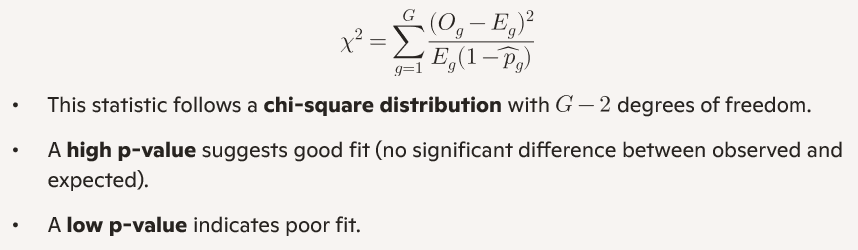

Is the Hosmer-Lemeshow Test in statsmodels?
- statsmodels does not have a built-in Hosmer-Lemeshow test function as of now.
- However, you can easily implement it using Python and your fitted GLM model

The Hosmer-Lemeshow test uses a hypothesis testing framework: 
- Null Hypothesis (\(H_{0}\)): There is no significant difference between the observed and expected frequencies in the groups; the model is a good fit for the data.

- Alternative Hypothesis (\(H_{a}\)): There is a significant difference; the model is a poor fit for the data. 

In [ ]:
pred_probs = res.predict(X)

# Number of groups (deciles)
g = 10

data = pd.DataFrame({'y': y, 'prob': pred_probs})
data['group'] = pd.cut(data['prob'], g, labels=False)

# Calculate observed and expected events in each group
obs = data.groupby('group')['y'].sum()
exp = data.groupby('group')['prob'].sum()
n = data.groupby('group').size()
# Hosmer-Lemeshow statistic
hl_stat = ((obs - exp) ** 2 / (exp * (1 - exp / n))).sum()
df = g - 2
p_value = chi2.sf(hl_stat, df)

print(f"Hosmer-Lemeshow statistic: {hl_stat:.2f}")
print(f"Degrees of freedom: {df:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print('Null hypothesis rejected!!!. There is a significant difference; the model is a poor fit for the data.')
if p_value >= 0.05:
    print('Faile to reject null hypothesis!!!. There is no\n\
significant difference between the observed and \n\
expected frequencies in the groups; the model \n\
is a good fit for the data')

Hosmer-Lemeshow statistic: 13.73
Degrees of freedom: 8.0000
p-value: 0.0890
Faile to reject null hypothesis. There is no
significant difference between the observed and 
expected frequencies in the groups; the model 
is a good fit for the data


#### Diagnostic Checking in Logistic Regression

##### deviance residual

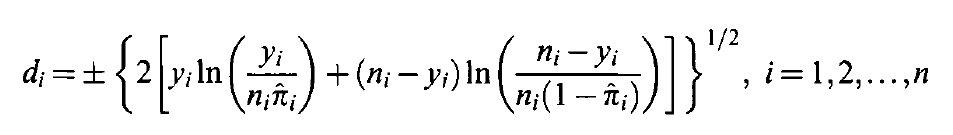

##### a Pearson residual

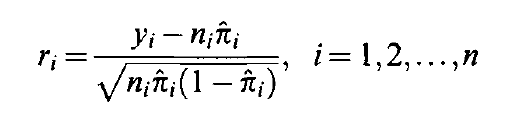

##### hat matrix analog for logistic regression

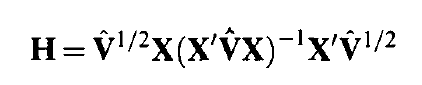

##### standardized Pearson residual

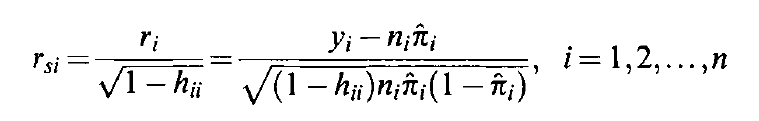

Interpretation Tips
- Residual > 2: Possible outlier
- Residual > 3: Strong candidate for influence diagnostics
- Plot standardized residuals vs. fitted values to check for patterns or heteroscedasticity.


In [ ]:
# Get deviance residuals
deviance_resid = res.resid_deviance

# Get Pearson residuals
pearson_resid = res.resid_pearson

# Hat matrix analog
Hat_matrix  = res.get_hat_matrix_diag(observed=True)

# Standardized Pearson residuals
std_pearson_resid = pearson_resid / np.sqrt(1 - Hat_matrix)
#print(std_pearson_resid)

print(f'Possible outlier {std_pearson_resid[abs(std_pearson_resid) > 2].values} {std_pearson_resid[abs(std_pearson_resid) > 2].index}')
print(f'Strong candidate for influence diagnostic {std_pearson_resid[abs(std_pearson_resid) > 3].values} {std_pearson_resid[abs(std_pearson_resid) > 3].index}')

Possible outlier [-3.03016505] Index([23], dtype='int64')
Strong candidate for influence diagnostic [-3.03016505] Index([23], dtype='int64')


In [ ]:
# calue @23
df.iloc[std_pearson_resid[abs(std_pearson_resid) > 3].index]


,REMISS,CELL,SMEAR,INFIL,LI,BLAST,TEMP
23,0,0.95,0.32,0.3,1.6,0.89,0.99


### Plot yhat vs y:

where yhat = Variance Functions

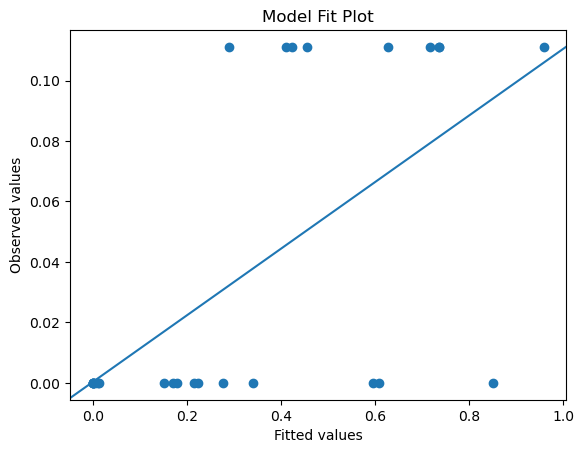

In [ ]:
from statsmodels.graphics.api import abline_plot

nobs = res.nobs
# Variance Functions
yhat = res.mu
fy = y/y.sum()

fig, ax = plt.subplots()
ax.scatter(yhat, fy)
line_fit = sm.OLS(fy, sm.add_constant(yhat, prepend=True)).fit()
abline_plot(model_results=line_fit, ax=ax)

ax.set_title("Model Fit Plot")
ax.set_ylabel("Observed values")
ax.set_xlabel("Fitted values");

### Plot yhat vs. Pearson residuals:

Text(0.5, 0, 'Fitted values')

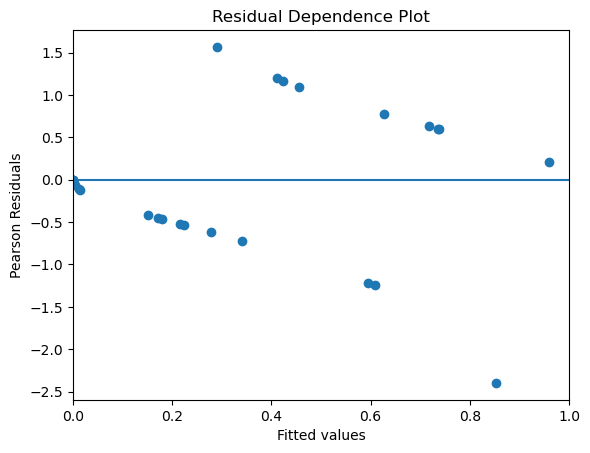

In [ ]:
fig, ax = plt.subplots()
ax.scatter(yhat, res.resid_pearson)
ax.hlines(0, 0, 1)
ax.set_xlim(0, 1)
ax.set_title("Residual Dependence Plot")
ax.set_ylabel("Pearson Residuals")
ax.set_xlabel("Fitted values")

### Histogram of standardized deviance residuals:

Skewness resid: 0.0057
Kurtosis resid: -0.6732
Skewness resid_std: 0.0057
Kurtosis resid_std: -0.6732


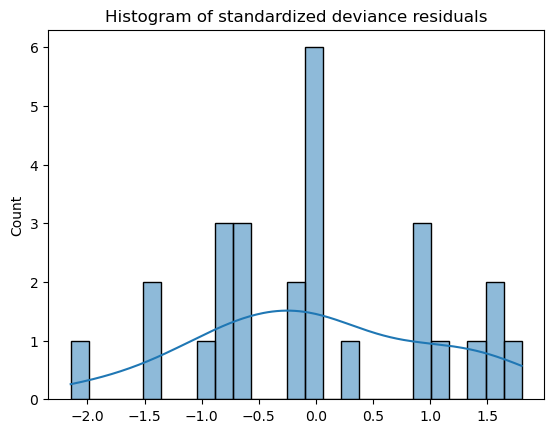

In [ ]:
from scipy import stats

fig, ax = plt.subplots()

resid = res.resid_deviance.copy()
resid_std = stats.zscore(resid)

#from scipy.stats import skew, kurtosis
skewness = skew(resid)
# Kurtosis (default is Fisher's definition: normal = 0)
kurt = kurtosis(resid)
print(f"Skewness resid: {skewness:.4f}")
print(f"Kurtosis resid: {kurt:.4f}")

#from scipy.stats import skew, kurtosis
skewness = skew(resid_std)
# Kurtosis (default is Fisher's definition: normal = 0)
kurt = kurtosis(resid_std)
print(f"Skewness resid_std: {skewness:.4f}")
print(f"Kurtosis resid_std: {kurt:.4f}")

sns.histplot(resid_std, bins=25,kde=True)
ax.set_title("Histogram of standardized deviance residuals");

Skewness – Asymmetry of the Distribution
Skewness tells you whether your data leans left or right

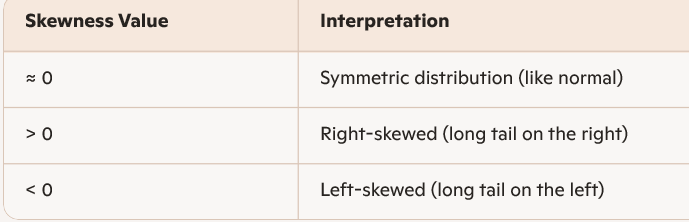

In result is skewness = 0.0057 ~ 0(approx), the distribution is moderately Symmetric distribution (like normal).

Kurtosis – Tailedness of the Distribution
Kurtosis measures how heavy or light the tails are compared to a normal distribution:

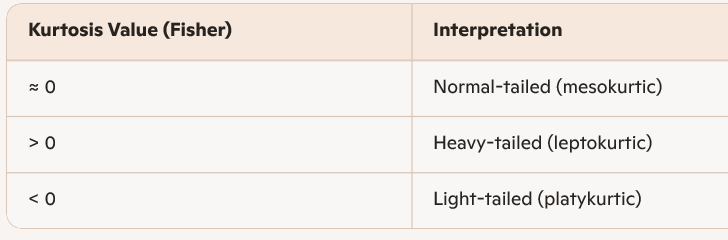

Note:
- Fisher’s definition: normal distribution has kurtosis = 0
- Pearson’s definition: normal distribution has kurtosis = 

In result is kurtosis < 0 Light-tailed (platykurtic)


#### QQ Plot of Deviance Residuals:

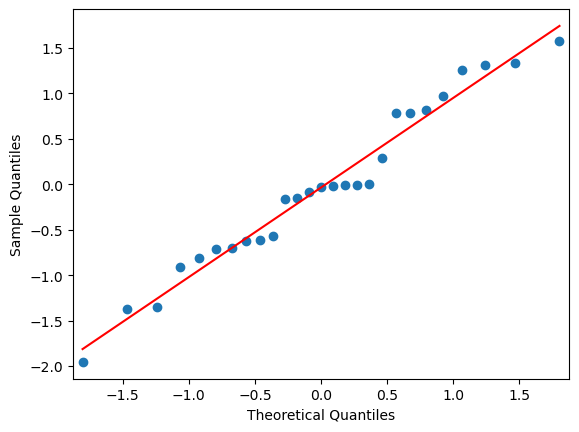

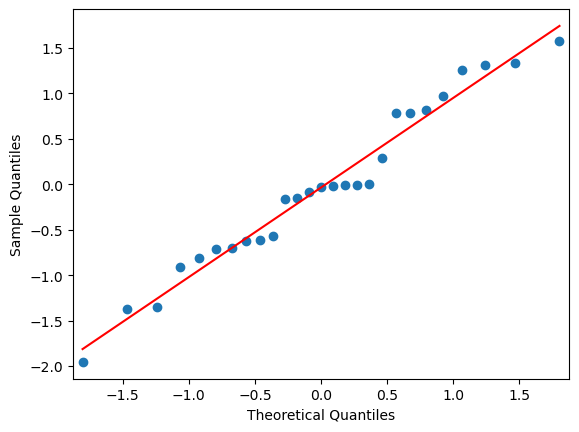

In [ ]:
from statsmodels import graphics
resid = res.resid_deviance.copy()
graphics.gofplots.qqplot(resid, line="r")

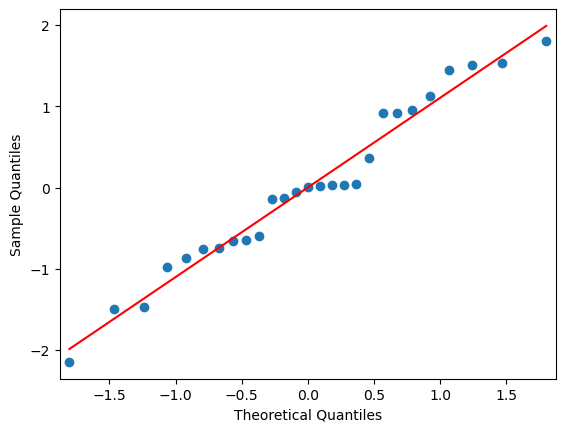

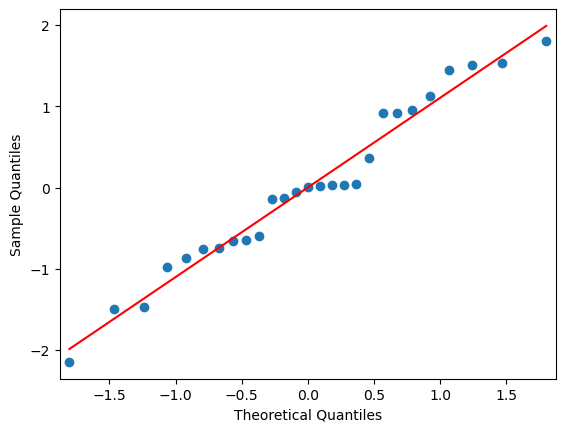

In [ ]:
from statsmodels import graphics
resid_std = stats.zscore(resid)
graphics.gofplots.qqplot(resid_std, line="r")

#### Influence Measures for GLM

In [ ]:
infl = res.get_influence(observed=False)
summ_df = infl.summary_frame()
summ_df.sort_values("cooks_d", ascending=False)[:10]

,dfb_const,dfb_CELL,dfb_SMEAR,dfb_INFIL,dfb_LI,dfb_BLAST,dfb_TEMP,cooks_d,standard_resid,hat_diag,dffits_internal
1,1.004638,-1.586128,-1.581113,1.474195,-0.355827,0.378070,0.108769,1.007086,1.885335,0.664800,2.655112
23,-0.572421,-0.928585,-0.797176,0.877109,-0.885247,-0.533119,1.146186,0.783899,-3.030165,0.374069,-2.342501
7,0.917115,0.504537,0.552158,-0.605327,-0.642076,1.124852,-1.188589,0.741673,-1.896945,0.590631,-2.278532
22,-0.705460,0.292563,0.249395,-0.255834,-0.025392,-0.448352,0.517206,0.162314,1.816588,0.256120,1.065927
14,-0.540038,0.272171,0.360005,-0.396639,-0.348407,0.244511,0.376269,0.143676,-1.500115,0.308879,-1.002863
6,0.239677,0.010885,0.068957,-0.052986,-0.283132,0.483645,-0.246321,0.128814,1.408051,0.312622,0.949578
25,-0.066180,0.065121,-0.030761,0.052858,0.341693,-0.652021,0.015413,0.107007,1.407298,0.274424,0.865477
0,-0.139275,0.360701,0.422537,-0.417949,0.217602,0.103173,-0.107017,0.086035,0.822530,0.470944,0.776044
15,-0.159229,0.001120,0.011895,-0.016529,-0.045259,0.304671,0.152374,0.080397,0.841404,0.442875,0.750186
11,-0.044863,0.230949,0.151050,-0.149981,0.149294,0.027214,-0.112423,0.054446,-0.634734,0.486119,-0.617352


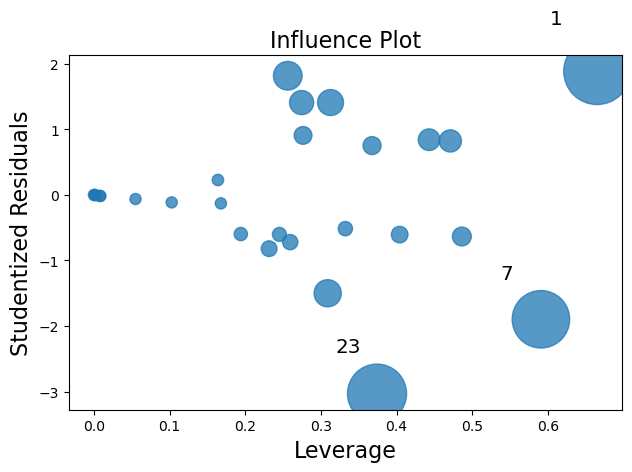

In [ ]:
fig = infl.plot_influence()
fig.tight_layout(pad=1.0)

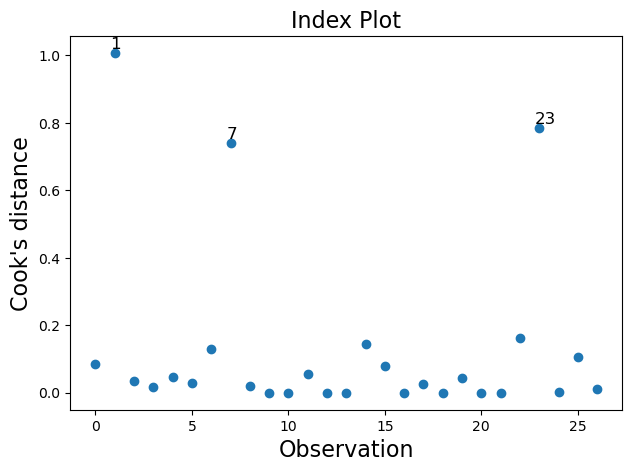

In [ ]:
fig = infl.plot_index(y_var="cooks", threshold=2 * infl.cooks_distance[0].mean())
fig.tight_layout(pad=1.0)

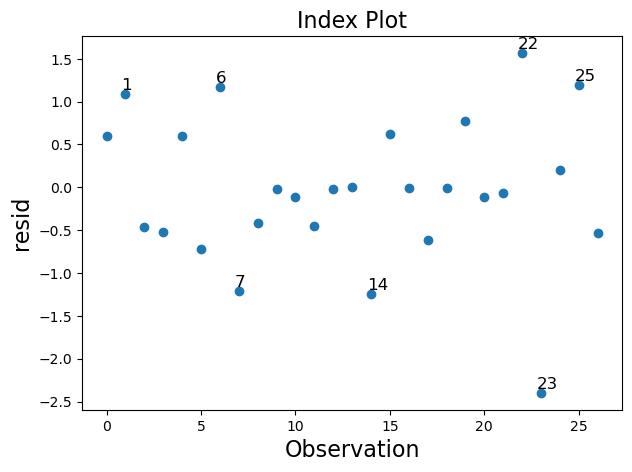

In [ ]:
fig = infl.plot_index(y_var="resid", threshold=1)
fig.tight_layout(pad=1.0)

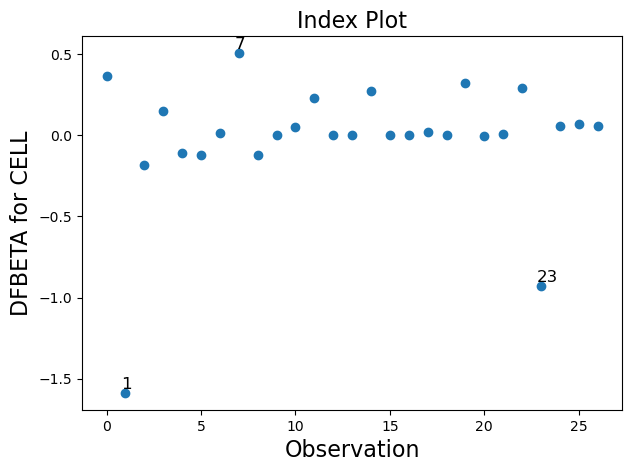

In [ ]:
fig = infl.plot_index(y_var="dfbeta", idx=1, threshold=0.5)
fig.tight_layout(pad=1.0)

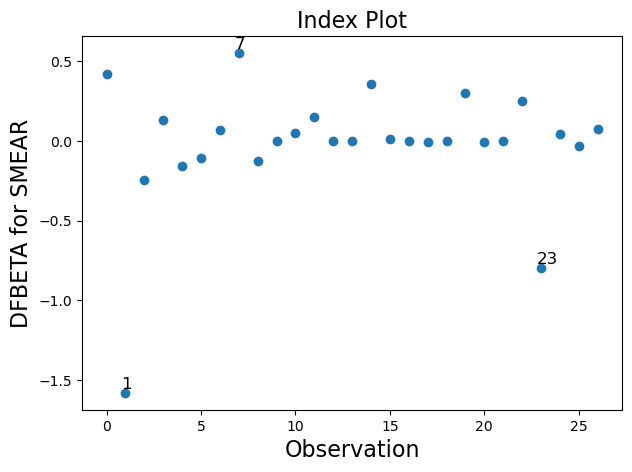

In [ ]:
fig = infl.plot_index(y_var="dfbeta", idx=2, threshold=0.5)
fig.tight_layout(pad=1.0)

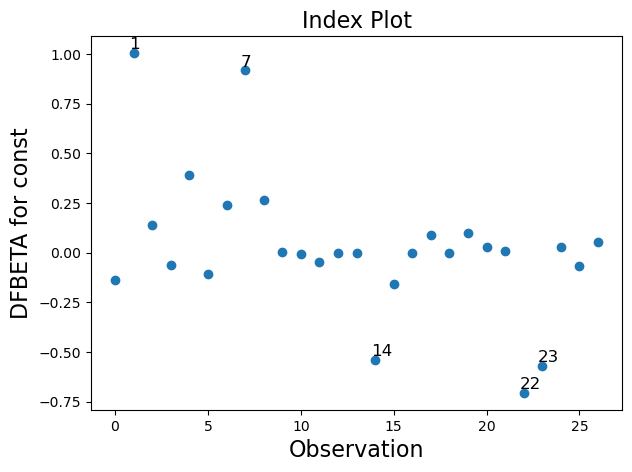

In [ ]:
fig = infl.plot_index(y_var="dfbeta", idx=0, threshold=0.5)
fig.tight_layout(pad=1.0)

# Delta plot
# Receiver Operating Characteristic Curve
# Confusions matrix

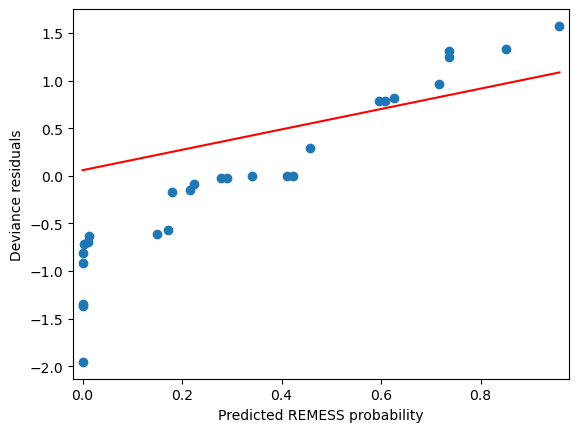

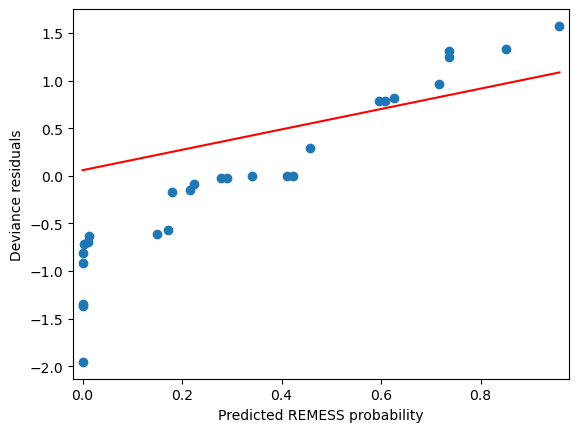

In [ ]:
from statsmodels.graphics.gofplots import qqplot_2samples
deviance_residuals = res.resid_deviance.copy()
predicted_probs = res.predict(X)
pp_x = sm.ProbPlot(predicted_probs)
pp_y = sm.ProbPlot(deviance_residuals)
qqplot_2samples(data1 = pp_x, #x-axis
                data2 = pp_y,# y axis
                xlabel="Predicted REMESS probability", 
                ylabel='Deviance residuals', 
                line= 'q', # {None, “45”, “s”, “r”, q”}
                ax=None
                )

#### What Is Delta Chi-Square ?

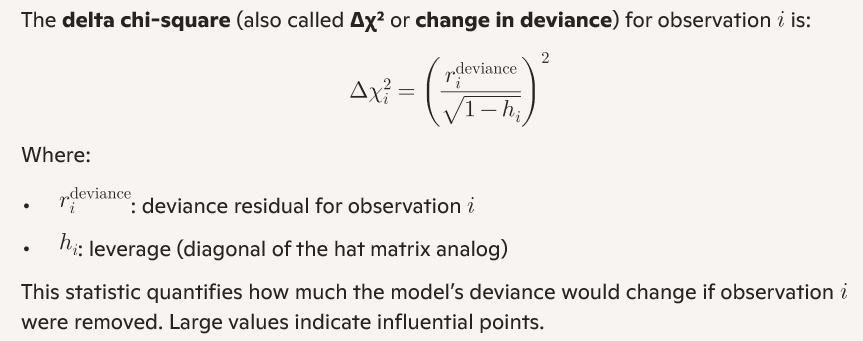

#### Interpretation

- Δχ² > 4: Potentially influential
- Δχ² > 10: Strong candidate for further investigation


In [ ]:
Leavrage = Hat_matrix
delta_chi_square = np.square(res.resid_pearson)/(1 - Leavrage)
print(f'Potentially influential: {delta_chi_square[delta_chi_square > 4]}')
print(f'Strong candidate for further investigation {delta_chi_square[delta_chi_square > 10]}')

Potentially influential: 23    9.1819
dtype: float64
Strong candidate for further investigation Series([], dtype: float64)


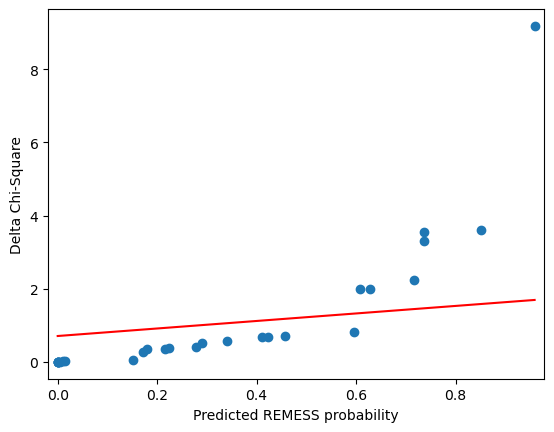

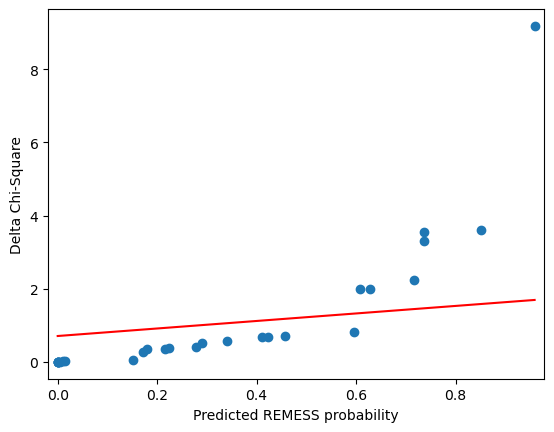

In [ ]:
pp_x = sm.ProbPlot(predicted_probs)
pp_y = sm.ProbPlot(delta_chi_square)
qqplot_2samples(data1 = pp_x, #x-axis
                data2 = pp_y,# y axis
                xlabel="Predicted REMESS probability", 
                ylabel='Delta Chi-Square', 
                line= 'q', # {None, “45”, “s”, “r”, q”}
                ax=None
                )

### Delta deviance

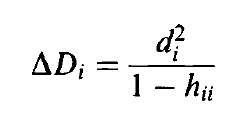

In [374]:
delta_deviance = np.square(res.resid_deviance)/(1 - Leavrage)

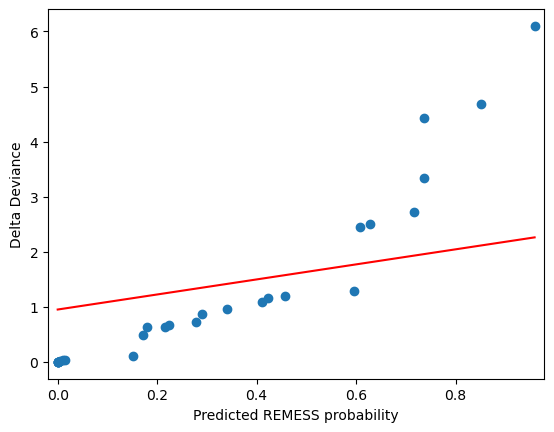

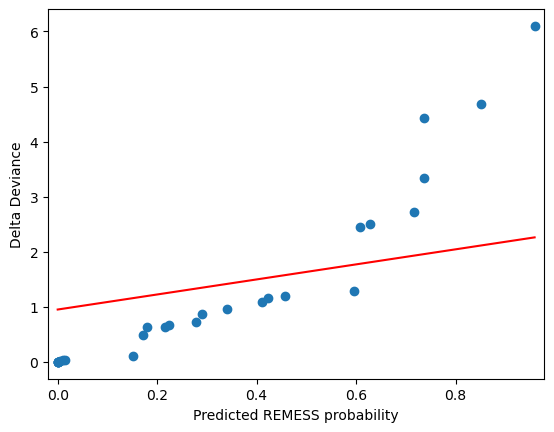

In [375]:
pp_x = sm.ProbPlot(predicted_probs)
pp_y = sm.ProbPlot(delta_deviance)
qqplot_2samples(data1 = pp_x, #x-axis
                data2 = pp_y,# y axis
                xlabel="Predicted REMESS probability", 
                ylabel='Delta Deviance', 
                line= 'q', # {None, “45”, “s”, “r”, q”}
                ax=None
                )

#### Delata of beta

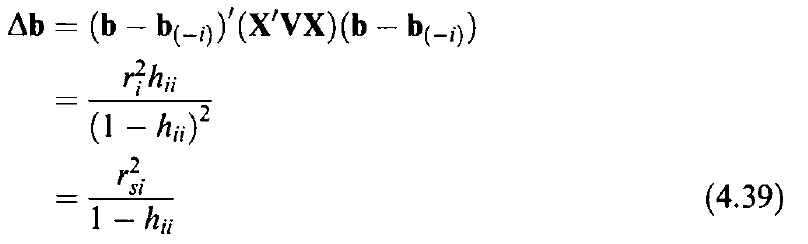

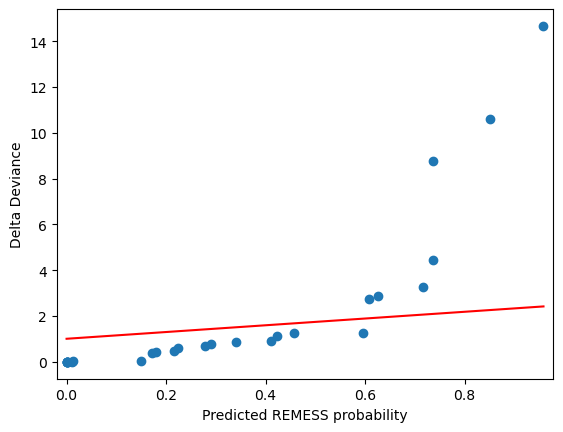

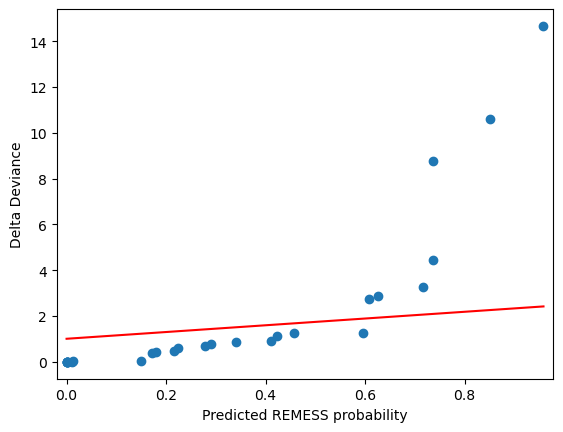

In [376]:
delata_beta = np.square(std_pearson_resid)/(1 - Leavrage)

pp_x = sm.ProbPlot(predicted_probs)
pp_y = sm.ProbPlot(delata_beta)
qqplot_2samples(data1 = pp_x, #x-axis
                data2 = pp_y,# y axis
                xlabel="Predicted REMESS probability", 
                ylabel='Delta Deviance', 
                line= 'q', # {None, “45”, “s”, “r”, q”}
                ax=None
                )

#### Plot Delta Chi square and Leverage


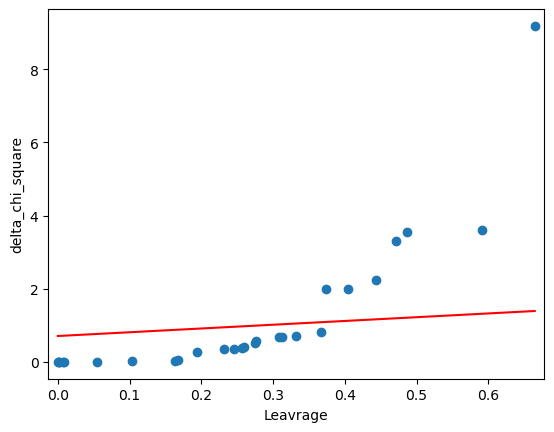

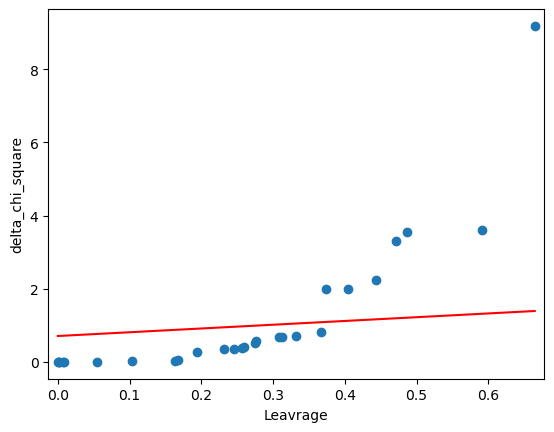

In [378]:
pp_x = sm.ProbPlot(Leavrage)
pp_y = sm.ProbPlot(delta_chi_square)
qqplot_2samples(data1 = pp_x, #x-axis
                data2 = pp_y,# y axis
                xlabel="Leavrage", 
                ylabel='delta_chi_square', 
                line= 'q', # {None, “45”, “s”, “r”, q”}
                ax=None
                )

Similarly plot

Plot of Delta deviance D, versus leverag

#### What Is a ROC Curve?

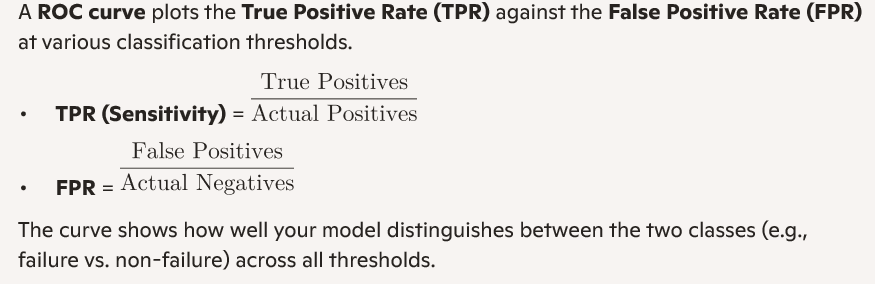

How to Interpret the ROC Curve

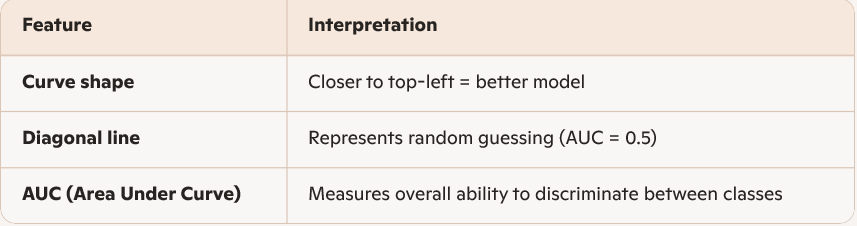

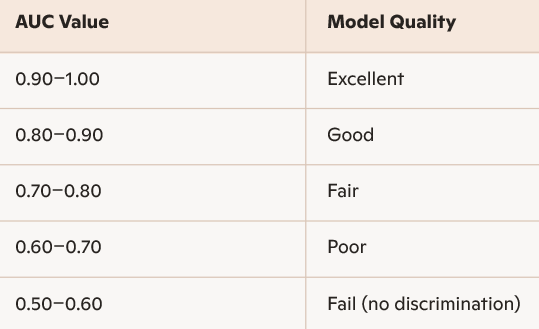

AUC Score Interpretation 0.895
If AUC is 0.87, your model has good 
discriminatory power—it can distinguish 
between failures and non-failures 87% of the time.


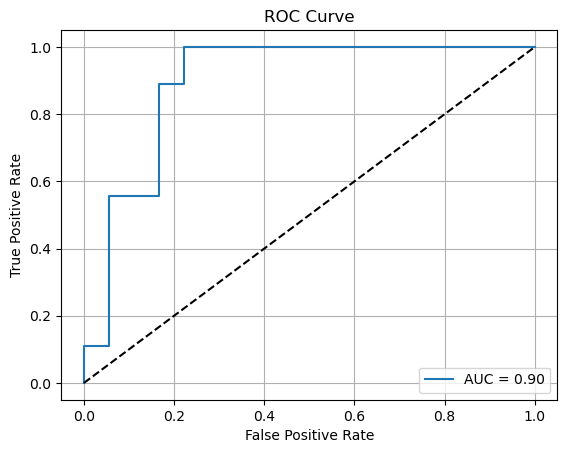

In [384]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y, predicted_probs)
#print(f'false +Ve rate:{fpr} True +Ve Rate {tpr} @ threshold value {thresholds}')
auc = roc_auc_score(y, predicted_probs)
print(f'AUC Score Interpretation {round(auc,3)}')
if auc > 0.87:
    print('If AUC is 0.87, your model has good \n\
discriminatory power—it can distinguish \n\
between failures and non-failures 87% of the time.')
# Plot
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()


Interpreting the Confusion Matrix:

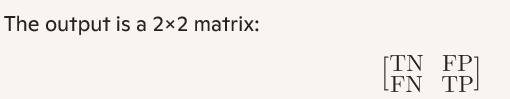

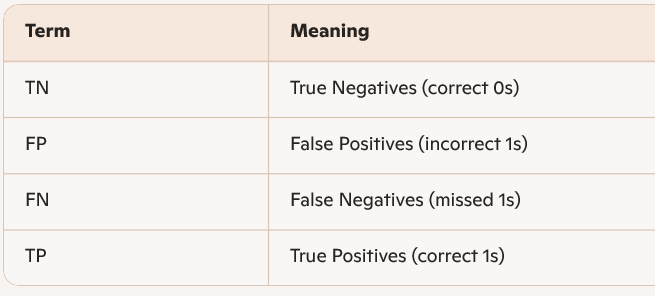





In [386]:
# Confusion matrix
threshold_ = 0.5
y_pred_binary = (predicted_probs >= threshold_).astype(int)
cm = confusion_matrix(y, y_pred_binary)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y, y_pred_binary))


Confusion Matrix:
[[15  3]
 [ 4  5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        18
           1       0.62      0.56      0.59         9

    accuracy                           0.74        27
   macro avg       0.71      0.69      0.70        27
weighted avg       0.73      0.74      0.74        27

